# Descriptive Answers

Questions and their resulting answers from our exploration of our data, along with visuals and mathematical evidence.

## Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import os
import glob


# set style for Seaborn
colour_palette = ["#42698E", "#FF8552", "#7C9FC1", "#D6E5F1", "#C0D4E7", "#211A1D"]
sns.set_theme(style="whitegrid", palette=colour_palette, font="Segoe UI", font_scale=1.1)

## Functions

In [2]:
### functions ###
    
def combine_csv_in_folder(data_folder: str, output_file: str="transactions.csv") -> None:
    """
    
    Combine the all the CSVs in data_folder into a single CSV.
    Assuming all the CSVs being combined have the same format.
    
    Adapted from code by: Ishfaq
    
    Input:
        data_folder (str): Name of the folder with all the CSVs.
        output_file (str): Name of the CSV of all the CSVs.
        
    Returns:
        None
        
    """
    # get a list of all CSVs in the data_folder
    all_files = glob.glob(os.path.join(data_folder, "**", "*.csv"), recursive=True)
    print(f"Found {len(all_files)} CSV files.\n")

    # iterate through each CSV, read the CSV, add a column with the demographic group name (folder name)
    dfs = []
    for fp in sorted(all_files):
        print("Loading:", fp)
        df = pd.read_csv(fp)
        folder = os.path.basename(os.path.dirname(fp))   # e.g. cleaned_50up_f_r
        area_type = folder[-1]
        if area_type == "r":
            df["area_type"] = "rural"
        elif area_type == "u":
            df["area_type"] = "urban"
        dfs.append(df)
    
    # combine all the DataFrames into a single one
    data = pd.concat(dfs, ignore_index=True)
    
    # save the combined data DataFrame as a CSV
    data.to_csv(output_file, index=False)
    print(f"CSV files combined and saved to {output_file}.")

## Load Data

In [3]:
# paths
DATA_ROOT = "cleaned_data_files"
combined_data_path = "transactions.csv"

# check if combined data CSV alreday exists and if not make it
if not os.path.isfile(combined_data_path):
    combine_csv_in_folder(DATA_ROOT, combined_data_path)

In [4]:
# load data
df = pd.read_csv(combined_data_path)

In [5]:
# view the first few rows
display(df.head())

# get shape of data
print(f"Data Shape: {df.shape}\n")

# check for missing values
print(f"Number of Missing Values per Feature:\n{df.isnull().sum()}\n")

# get column data types
print("Feature Data Info:")
df.info()

# get descriptive stats for numeric columns
print(f"\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

,cc_num,gender,city,state,zip,lat,long,city_pop,job,category,amt,is_fraud,merchant,merch_lat,merch_long,trans_datetime,age,area_type
0,2331599965047738,F,Ashton,MD,20861,39.1510,-76.9924,1875,Neurosurgeon,gas_transport,76.49,0,"Lind, Huel and McClure",40.138571,-77.284546,2019-01-01 01:03:49,37,rural
1,4438983640376137917,F,Quentin,PA,17083,40.2764,-76.4112,109,Broadcast journalist,gas_transport,6.96,0,"Stroman, Hudson and Erdman",39.631906,-76.851074,2019-01-01 01:15:25,41,rural
2,2331599965047738,F,Ashton,MD,20861,39.1510,-76.9924,1875,Neurosurgeon,gas_transport,80.91,0,"Raynor, Feest and Miller",39.719848,-77.528245,2019-01-01 01:19:08,37,rural
3,213160930685388,F,Bloomingrose,WV,25024,38.1412,-81.6367,586,Midwife,gas_transport,98.28,0,Bernhard Inc,38.637231,-81.161895,2019-01-01 01:21:43,30,rural
4,4438983640376137917,F,Quentin,PA,17083,40.2764,-76.4112,109,Broadcast journalist,gas_transport,50.02,0,Bernhard Inc,39.621815,-77.149117,2019-01-01 03:01:13,41,rural


Data Shape: (3478813, 18)

Number of Missing Values per Feature:
cc_num            0
gender            0
city              0
state             0
zip               0
lat               0
long              0
city_pop          0
job               0
category          0
amt               0
is_fraud          0
merchant          0
merch_lat         0
merch_long        0
trans_datetime    0
age               0
area_type         0
dtype: int64

Feature Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3478813 entries, 0 to 3478812
Data columns (total 18 columns):
 #   Column          Dtype  
---  ------          -----  
 0   cc_num          int64  
 1   gender          object 
 2   city            object 
 3   state           object 
 4   zip             int64  
 5   lat             float64
 6   long            float64
 7   city_pop        int64  
 8   job             object 
 9   category        object 
 10  amt             float64
 11  is_fraud        int64  
 12  merchant        ob

,cc_num,zip,lat,long,city_pop,amt,is_fraud,merch_lat,merch_long,age
count,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06,3.478813e+06
mean,3.829977e+17,5.141218e+04,3.747681e+01,-9.187338e+01,2.848557e+05,7.116761e+01,5.470544e-03,3.747696e+01,-9.187331e+01,3.883391e+01
std,1.254155e+18,2.979604e+04,5.065531e+00,1.611235e+01,5.479204e+05,1.680841e+02,7.376055e-02,5.097963e+00,1.612256e+01,1.770211e+01
min,6.040027e+10,1.027000e+03,1.955060e+01,-1.580174e+02,7.600000e+01,1.000000e+00,0.000000e+00,1.855116e+01,-1.588502e+02,8.000000e+00
25%,1.800754e+14,2.752900e+04,3.388420e+01,-9.811620e+01,1.786300e+04,9.130000e+00,0.000000e+00,3.387108e+01,-9.820568e+01,2.500000e+01
50%,3.522170e+15,4.811100e+04,3.831750e+01,-8.735260e+01,6.000200e+04,4.456000e+01,0.000000e+00,3.819555e+01,-8.723914e+01,3.700000e+01
75%,4.676428e+15,7.823900e+04,4.112570e+01,-7.995280e+01,2.222720e+05,8.210000e+01,0.000000e+00,4.118815e+01,-7.976854e+01,5.000000e+01
max,4.989104e+18,9.958600e+04,6.266820e+01,-6.726410e+01,2.906700e+06,5.294123e+04,1.000000e+00,6.366737e+01,-6.626601e+01,9.000000e+01


In [6]:
# check fraud distribution
fraud_counts = df["is_fraud"].value_counts()
print(f"Fraud Transaction Counts: {fraud_counts} \n")

fraud_rate = df['is_fraud'].mean()
print("Fraud Rate:", fraud_rate)

Fraud Transaction Counts: is_fraud
0    3459782
1      19031
Name: count, dtype: int64 

Fraud Rate: 0.00547054411950283


## Note on Unit of Analysis

The dataset is structured at the transaction level, meaning each row represents a transaction rather than a unique cardholder. As a result, some cardholders appear multiple times in the dataset. This may introduce dependence between observations because transactions from the same cardholder share characteristics such as age and location. Therefore, the statistical tests should be interpreted as describing patterns among transactions rather than independent individuals.

## Descriptive Question 1

**Question**: Do fraudulent transactions have higher amounts?

**Feature**: `amt` (numeric)

**Test**: Welch two-sample t-test

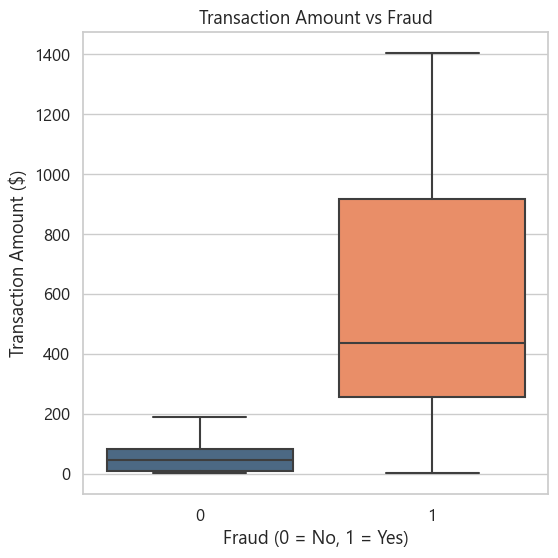

In [7]:
# visual inspection
plt.figure(figsize=(6, 6))

sns.boxplot(x="is_fraud", y="amt", data=df, showfliers=False)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount ($)")

plt.show()

In [8]:
# mathematical interpretation
fraud_amt = df[df["is_fraud"] == 1]["amt"]
nonfraud_amt = df[df["is_fraud"] == 0]["amt"]

# hypotheses
print("**Hypothesis Test for Transaction Amount vs Fraud**\n")
print("Null Hypothesis (H_0): The mean transaction amount is the same for fraudulent and non-fraudulent transactions.")
print("Alternative Hypothesis (H_A): The mean transaction amount for fraudulent transactions is greater than that for non-fraudulent transactions.\n")

# get means
print(f"Mean Amount for Fraud: ${fraud_amt.mean():.2f}")
print(f"Mean Amount for Non-Fraud: ${nonfraud_amt.mean():.2f}")

# two sample t-test assuming unequal variance
t_stat, p_value_two_sided = stats.ttest_ind(fraud_amt, nonfraud_amt, equal_var=False)
p_value_one_sided = p_value_two_sided / 2
print(f"\nt-statistic: {t_stat:.4f}")
print(f"One-sided p-value: {p_value_one_sided:.6f}")

# Cohen's d because large sample size
pooled_sd = np.sqrt(((fraud_amt.var() + nonfraud_amt.var()) / 2))
cohen_d = (fraud_amt.mean() - nonfraud_amt.mean()) / pooled_sd
print(f"Cohen's d: {cohen_d:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value_one_sided < alpha and t_stat > 0:
    print(f"\nSince p-value ({p_value_one_sided:.6f}) < {alpha}, reject the null hypothesis.")
    print("The fraudulent transaction amounts are statistically significantly larger than non-fraudulent transactions.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= {alpha}, we fail to reject the null hypothesis.")
    
print(f"Cohen's d of {cohen_d:.4f} indicates a large effect size, meaning the difference in transaction amounts is substantial and has practical significance.")

**Hypothesis Test for Transaction Amount vs Fraud**

Null Hypothesis (H_0): The mean transaction amount is the same for fraudulent and non-fraudulent transactions.
Alternative Hypothesis (H_A): The mean transaction amount for fraudulent transactions is greater than that for non-fraudulent transactions.

Mean Amount for Fraud: $537.98
Mean Amount for Non-Fraud: $68.60

t-statistic: 164.3480
One-sided p-value: 0.000000
Cohen's d: 1.5584
Alpha: 0.01

Since p-value (0.000000) < 0.01, reject the null hypothesis.
The fraudulent transaction amounts are statistically significantly larger than non-fraudulent transactions.
Cohen's d of 1.5584 indicates a large effect size, meaning the difference in transaction amounts is substantial and has practical significance.


**Answer**: Fraudulent transactions have significantly higher transaction amounts than non-fraudulent transactions. 

The Welch two-sample t-test comparing the mean transaction amount between fraudulent and non-fraudulent transactions shows a large difference in means (fraud mean = \\$537.98, non-fraud mean = \\$68.60). The test produced a t-statistic of 164.35 with a p-value < 0.000001, indicating strong statistical evidence against the null hypothesis.

The effect size is also very large (Cohen’s d = 1.5584), suggesting that fraudulent transactions tend to involve substantially larger amounts than non-fraudulent transactions.

## Descriptive Question 2

**Question**: Does fraud vary by transaction category?

**Feature**: `category` (catgeorical)

**Test**: Chi-square test of independence

In [9]:
# get fraud rate per category
category_stats = df.groupby("category")["is_fraud"].agg(["mean", "count"])
category_stats = category_stats.rename(columns={"mean": "fraud_rate","count": "transactions"})

# convert to percentage
category_stats["fraud_rate"] = category_stats["fraud_rate"] * 100

# print stats
print(category_stats.sort_values("fraud_rate", ascending=False))

# reset index and sort for plotting later
plot_category_stats = category_stats.reset_index()
plot_category_stats = plot_category_stats.sort_values("fraud_rate", ascending=False)

                fraud_rate  transactions
category                                
shopping_net      1.738435        256150
misc_net          1.519414        158877
grocery_pos       1.351777        327273
shopping_pos      0.660124        343572
gas_transport     0.514979        298459
travel            0.286782        110537
misc_pos          0.256638        228337
entertainment     0.223009        252905
personal_care     0.204369        246123
grocery_net       0.192546        148536
food_dining       0.171426        261338
health_fitness    0.161605        217196
kids_pets         0.144901        302965
home              0.135050        326545


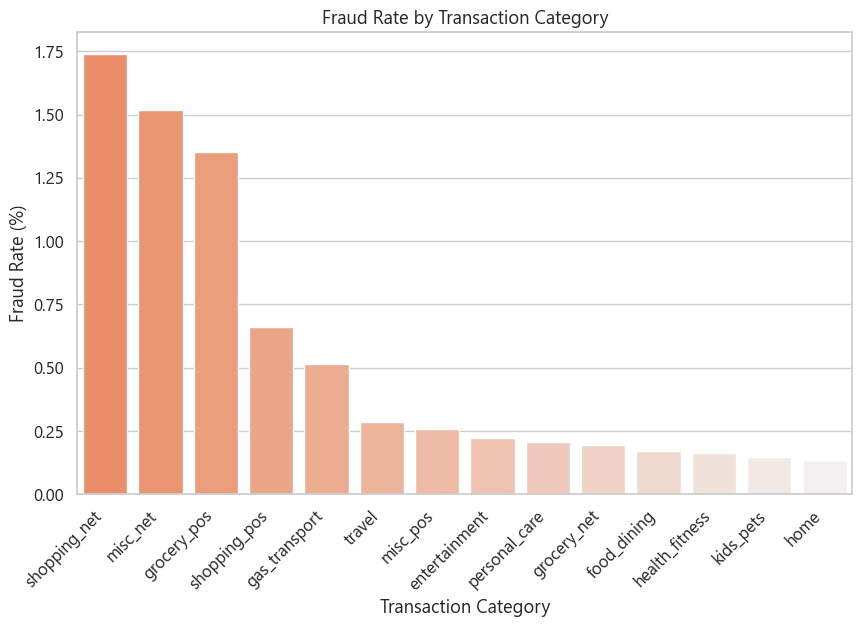

In [10]:
# visual inspection
plt.figure(figsize=(10, 6))
fraud_palette = sns.light_palette("#FF8552", n_colors=len(plot_category_stats), reverse=True)

sns.barplot(x="category", y="fraud_rate", data=plot_category_stats, palette=fraud_palette)
plt.xticks(rotation=45, ha="right")
plt.title("Fraud Rate by Transaction Category")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Transaction Category")

plt.show()

In [11]:
# mathematical interpretation
fraud_category_table = pd.crosstab(df["category"], df["is_fraud"])

# hypotheses
print("**Hypothesis Test for Transaction Category vs Fraud**\n")
print("Null Hypothesis (H_0): Fraudulent transactions are independent of transaction category.")
print("Alternative Hypothesis (H_A): Fraudulent transactions depend on transaction category.\n")

print("Fraud Rate by Category:")
print(category_stats)

# chi-sqaure test of independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(fraud_category_table)
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

# Cramer's V because of large sample size
n = fraud_category_table.sum().sum() 
min_dim = min(fraud_category_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"Cramer's V: {cramers_v:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value < alpha:
    print(f"\nSince p-value ({p_value:.6f}) < {alpha}, reject the null hypothesis.")
    print("There is statistical evidence that fraud transactions depend on transaction category.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= {alpha}, we fail to reject the null hypothesis.")

print(f"Cramer's V  of {cramers_v:.4f} indicates a weak association between fraud and transaction category, meaning fraud is slightly more likely in certain categories, but the association is not very strong.")

**Hypothesis Test for Transaction Category vs Fraud**

Null Hypothesis (H_0): Fraudulent transactions are independent of transaction category.
Alternative Hypothesis (H_A): Fraudulent transactions depend on transaction category.

Fraud Rate by Category:
                fraud_rate  transactions
category                                
entertainment     0.223009        252905
food_dining       0.171426        261338
gas_transport     0.514979        298459
grocery_net       0.192546        148536
grocery_pos       1.351777        327273
health_fitness    0.161605        217196
home              0.135050        326545
kids_pets         0.144901        302965
misc_net          1.519414        158877
misc_pos          0.256638        228337
personal_care     0.204369        246123
shopping_net      1.738435        256150
shopping_pos      0.660124        343572
travel            0.286782        110537

Chi-square statistic: 18469.7768
Degrees of freedom: 13
p-value: 0.000000
Cramer's V: 0.0

**Answer**: Fraud rates vary significantly across transaction categories. 

The chi-square test of independence indicates that fraud occurrence is associated with transaction category (χ² = 18469.78, df = 13, p-value < 0.000001). This means that the probability of a transaction being fraudulent is not evenly distributed across categories.

However, the effect size is small (Cramer's V = 0.0729), indicating that although the relationship is statistically significant, the strength of the association between transaction category and fraud is weak.

## Descriptive Question 3

**Question**: Is cardholder age related to fraud?

**Feature**: `age` (numeric)

**Test**: Welch two-sample t-test

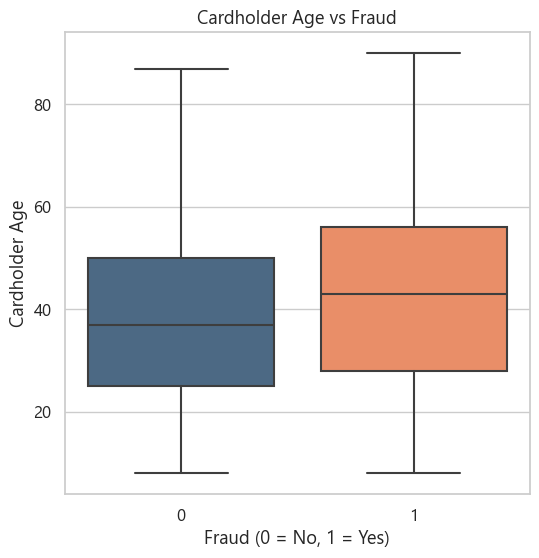

In [12]:
# visual inspection
plt.figure(figsize=(6, 6))

sns.boxplot(x="is_fraud", y="age", data=df, showfliers=False)
plt.title("Cardholder Age vs Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Cardholder Age")

plt.show()

In [13]:
# mathematical interpretation
fraud_age = df[df["is_fraud"] == 1]["age"]
nonfraud_age = df[df["is_fraud"] == 0]["age"]

# hypotheses
print("**Hypothesis Test for Cradholder Age vs Fraud**\n")
print("Null Hypothesis (H_0): The mean cardholder age is the same for fraudulent and non-fraudulent transactions.")
print("Alternative Hypothesis (H_A): The mean cardholder age for fraudulent transactions is greater than that for non-fraudulent transactions.\n")

# get means
print(f"Mean Age for Fraud: {fraud_age.mean():.2f}")
print(f"Mean Age for Non-Fraud: {nonfraud_age.mean():.2f}")

# two sample t-test assuming unequal variance
t_stat, p_value_two_sided = stats.ttest_ind(fraud_age, nonfraud_age, equal_var=False)
p_value_one_sided = p_value_two_sided / 2
print(f"\nt-statistic: {t_stat:.4f}")
print(f"One-sided p-value: {p_value_one_sided:.6f}")

# Cohen's d because large sample size
pooled_sd = np.sqrt(((fraud_age.var() + nonfraud_age.var()) / 2))
cohen_d = (fraud_age.mean() - nonfraud_age.mean()) / pooled_sd
print(f"Cohen's d: {cohen_d:.4f}")

# conclusion
alpha = 0.01
print(f"Alpha: {alpha}")

if p_value_one_sided < alpha and t_stat > 0:
    print(f"\nSince p-value ({p_value_one_sided:.6f}) < {alpha}, reject the null hypothesis.")
    print("The mean age for fraudulent transactions is statistically significantly older than that for non-fraudulent transactions.")
else:
    print(f"\nSince p-value ({p_value_one_sided:.6f}) >= {alpha}, we fail to reject the null hypothesis.")
    
print(f"Cohen's d of {cohen_d:.4f} indicates a small to medium effect. This suggests that fraudulent transactions tend to have slightly older cardholders, but the effect is moderate.")

**Hypothesis Test for Cradholder Age vs Fraud**

Null Hypothesis (H_0): The mean cardholder age is the same for fraudulent and non-fraudulent transactions.
Alternative Hypothesis (H_A): The mean cardholder age for fraudulent transactions is greater than that for non-fraudulent transactions.

Mean Age for Fraud: 43.61
Mean Age for Non-Fraud: 38.81

t-statistic: 34.9527
One-sided p-value: 0.000000
Cohen's d: 0.2624
Alpha: 0.01

Since p-value (0.000000) < 0.01, reject the null hypothesis.
The mean age for fraudulent transactions is statistically significantly older than that for non-fraudulent transactions.
Cohen's d of 0.2624 indicates a small to medium effect. This suggests that fraudulent transactions tend to have slightly older cardholders, but the effect is moderate.


**Answer**: Transactions associated with older cardholders are slightly more likely to be fraudulent.

The Welch two-sample t-test comparing the mean age associated with fraudulent and non-fraudulent transactions shows a statistically significant difference (fraud mean age = 43.61 years, non-fraud mean age = 38.81 years). The test produced a t-statistic of 34.95 with a p-value < 0.000001, providing strong statistical evidence against the null hypothesis.

However, the effect size is relatively small (Cohen’s d = 0.2624), indicating that although fraudulent transactions tend to be associated with slightly older cardholders, the magnitude of this difference is modest.

**Note**: Due to the large sample size, the statistical tests have very high power so we get p-values that are too small for Python to represent properly.

## Quick Cardholder-Level Check

In [14]:
# cardholder level aggregation
cardholder_df = df.groupby("cc_num").agg({
    "age": "first",    # age of cardholder
    "amt": "mean",     # average transaction amount per cardholder
    "is_fraud": "max"  # 1 if any transaction is fraudulent
}).reset_index()

# most frequent category per cardholder
def most_freq(series):
    return series.value_counts().idxmax()

cardholder_category = df.groupby("cc_num")["category"].agg(most_freq).reset_index()
cardholder_category.rename(columns={"category": "most_category"}, inplace=True)

cardholder_df = cardholder_df.merge(cardholder_category, on="cc_num")

In [15]:
fraud_amt_ch = cardholder_df[cardholder_df["is_fraud"] == 1]["amt"]
nonfraud_amt_ch = cardholder_df[cardholder_df["is_fraud"] == 0]["amt"]

# t-test
t_stat_amt, p_val_amt = stats.ttest_ind(fraud_amt_ch, nonfraud_amt_ch, equal_var=False)

# Cohen's d
pooled_sd_amt = np.sqrt((fraud_amt_ch.var() + nonfraud_amt_ch.var()) / 2)
cohen_d_amt = (fraud_amt_ch.mean() - nonfraud_amt_ch.mean()) / pooled_sd_amt

print("** Amount Test (Cardholder-Level) **")
print(f"Mean Amount Fraud: ${fraud_amt_ch.mean():.2f}")
print(f"Mean Amount Non-Fraud: ${nonfraud_amt_ch.mean():.2f}")
print(f"t-statistic: {t_stat_amt:.4f}, p-value: {p_val_amt:.6f}, Cohen's d: {cohen_d_amt:.4f}")

** Amount Test (Cardholder-Level) **
Mean Amount Fraud: $139.50
Mean Amount Non-Fraud: $67.52
t-statistic: 15.0250, p-value: 0.000000, Cohen's d: 0.5478


Cardholders who experienced fraud have significantly higher average transaction amounts than those who did not. 

The Welch t-test comparing the mean average transaction amount per cardholder shows a strong difference (fraud mean = \\$139.50, non-fraud mean = \\$67.52), with a t-statistic of 15.03 and a p-value < 0.000001. 

The effect size is medium (Cohen’s d = 0.5478), indicating that cardholders who experience fraud tend to have substantially higher average transaction amounts than non-fraud cardholders.

In [16]:
# pick most frequent category per cardholder
def most_freq(cat_series):
    return cat_series.value_counts().idxmax()

cardholder_category = df.groupby("cc_num")["category"].agg(most_freq).reset_index()
cardholder_df = cardholder_df.merge(cardholder_category, on="cc_num")

# chi-square test
fraud_category_table_ch = pd.crosstab(cardholder_df["category"], cardholder_df["is_fraud"])
chi2_stat_ch, p_val_ch, dof_ch, expected_ch = stats.chi2_contingency(fraud_category_table_ch)

# Cramer's V
n_ch = fraud_category_table_ch.sum().sum()
min_dim_ch = min(fraud_category_table_ch.shape) - 1
cramers_v_ch = np.sqrt(chi2_stat_ch / (n_ch * min_dim_ch))

print("** Category Test (Cardholder-Level) **")
print(f"Chi2: {chi2_stat_ch:.4f}, p-value: {p_val_ch:.6f}, Cramer's V: {cramers_v_ch:.4f}")

** Category Test (Cardholder-Level) **
Chi2: 2.8641, p-value: 0.984444, Cramer's V: 0.0379


At the cardholder level, fraud occurrence does not appear to vary across the most frequently used transaction categories.

The chi-square test shows chi-square = 2.86, p-value = 0.9844, and Cramer's V = 0.0379. 

Since the p-value is much greater than 0.01, we fail to reject the null hypothesis. The effect size is very small, indicating that the association between fraud and cardholder category is negligible.

**Note**: We should stick to transaction level statistical tests for this test.

In [17]:
fraud_age_ch = cardholder_df[cardholder_df["is_fraud"] == 1]["age"]
nonfraud_age_ch = cardholder_df[cardholder_df["is_fraud"] == 0]["age"]

# t-test
t_stat_age, p_val_age = stats.ttest_ind(fraud_age_ch, nonfraud_age_ch, equal_var=False)

# Cohen's d
pooled_sd_age = np.sqrt((fraud_age_ch.var() + nonfraud_age_ch.var()) / 2)
cohen_d_age = (fraud_age_ch.mean() - nonfraud_age_ch.mean()) / pooled_sd_age

print("** Age Test (Cardholder-Level) **")
print(f"Mean Age Fraud: {fraud_age_ch.mean():.2f}")
print(f"Mean Age Non-Fraud: {nonfraud_age_ch.mean():.2f}")
print(f"t-statistic: {t_stat_age:.4f}, p-value: {p_val_age:.6f}, Cohen's d: {cohen_d_age:.4f}")

** Age Test (Cardholder-Level) **
Mean Age Fraud: 43.39
Mean Age Non-Fraud: 41.21
t-statistic: 0.6100, p-value: 0.545386, Cohen's d: 0.1065


Cardholders who experienced fraud are slightly older on average than those who did not, but the difference is not statistically significant.

The Welch t-test shows that the mean age for fraud cardholders is 43.39 years versus 41.21 years for non-fraud cardholders (t-statistic = 0.61, p-value = 0.5454). 

The effect size is very small (Cohen’s d = 0.1065), indicating that age does not meaningfully distinguish between cardholders who experience fraud and those who do not at the cardholder level.

**Note**: This is likely the best option for age.

## Handle Skew

In [18]:
# Mann-Whitney U test
u_stat_amt, p_val_amt = stats.mannwhitneyu(fraud_amt_ch, nonfraud_amt_ch, alternative="greater")

# Cohen's d for effect size
pooled_sd_amt = np.sqrt((fraud_amt_ch.var() + nonfraud_amt_ch.var()) / 2)
cohen_d_amt = (fraud_amt_ch.mean() - nonfraud_amt_ch.mean()) / pooled_sd_amt

# Print results in your style
print("** Amount Test (Cardholder-Level, Mann–Whitney) **")
print(f"Mean Amount Fraud: ${fraud_amt_ch.mean():.2f}")
print(f"Mean Amount Non-Fraud: ${nonfraud_amt_ch.mean():.2f}")
print(f"Mann-Whitney U statistic: {u_stat_amt:.0f}, p-value: {p_val_amt:.6f}, Cohen's d: {cohen_d_amt:.4f}")

** Amount Test (Cardholder-Level, Mann–Whitney) **
Mean Amount Fraud: $139.50
Mean Amount Non-Fraud: $67.52
Mann-Whitney U statistic: 49664, p-value: 0.000594, Cohen's d: 0.5478


Fraudulent cardholders have significantly higher average transaction amounts than non-fraud cardholders. Even using a non-parametric test that does not assume normality, the difference is statistically significant and the effect size indicates a moderate practical difference.

## Comparison of Transaction-Level vs Cardholder-Level Analysis

When analyzing fraud, the choice between transaction-level and cardholder-level analysis affects both the validity of statistical tests and the interpretation of results.

### Numeric Features (Amount, Age)

For numeric features like transaction amount or cardholder age, each cardholder may have multiple transactions. In a transaction-level analysis, these repeated transactions are treated as independent observations. However, transactions from the same cardholder are not truly independent, because individual spending habits, credit limits, and fraud susceptibility can create correlations across transactions. Using transaction-level t-tests in this scenario inflates sample size and can produce artificially low p-values, exaggerating statistical significance.

Aggregating numeric features to the cardholder level (for example, taking the average transaction amount per cardholder) ensures that each cardholder contributes a single observation, restoring independence. While this aggregation may dilute the signal from individual fraudulent transactions, it provides a more statistically defensible test. For age, cardholder-level analysis is also appropriate because a cardholder’s age is constant across transactions.

### Categorical Features (Transaction Category)

For categorical features, aggregation at the cardholder level can be misleading. If a cardholder has only one or a few fraudulent transactions among many non-fraud transactions, summarizing their category usage (for example, using the most frequent category) can hide the categories where fraud actually occurs. Transaction-level analysis preserves the real distribution of fraudulent transactions across categories, highlighting which types of transactions are at higher risk. Therefore, statistical tests like chi-square should generally be performed at the transaction level for categorical features.

### Effect Sizes and Practical Significance

Across both numeric and categorical features, it is important to report effect sizes (such as Cohen’s d for numeric features or Cramer’s V for categorical features) in addition to p-values. This ensures that conclusions reflect practical significance and not just statistical significance.

### Overall Recommendation

For numeric features (amount, age), use cardholder-level tests to satisfy independence assumptions, optionally supplementing with descriptive transaction-level statistics to show per-transaction magnitude.

For categorical features (transaction category), use transaction-level analysis to accurately capture where fraud occurs.

Always combine statistical tests with descriptive statistics and effect sizes to provide a clear and defensible analysis.


**Summary**: Statistical tests are useful for understanding patterns in fraud, but the level of aggregation must match the assumptions of the test and the nature of the data. Cardholder-level aggregation ensures valid inference for numeric features, while transaction-level analysis preserves signal for categorical features where rare fraud events are critical.

## References
- https://seaborn.pydata.org/tutorial/aesthetics.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind
- https://stackoverflow.com/a/52680007